# Macro-Arbitrage Strategy Backtest (Monte Carlo & Permutation)

This notebook performs a rigorous backtest of the **Macro-Arbitrage (Lead-Lag)** strategy.
It goes beyond simple P&L calculation by using:
1.  **Monte Carlo Simulation:** To estimate the probability of drawdown and risk of ruin.
2.  **Permutation Tests:** To validate that the strategy's edge is statistically significant and not due to random noise.

## Strategy Logic & Upgrades
The strategy exploits the time delay of information flow between "Leader" assets (Big Caps/Sector ETFs) and "Laggard" assets (Small Caps).

### Core Logic
1.  **Trigger:** Monitor the Leader for a significant move (Z-Score > 2.0).
2.  **Dislocation:** Check if the Laggard has *not* yet moved significantly.
3.  **Execution:** Enter a trade on the Laggard in the direction of the Leader.

### Recent Upgrades
*   **Dynamic Volatility Scaling:** Instead of a fixed % threshold (which misses trades in low vol and overtrades in high vol), we now use a **Z-Score** based on rolling volatility.
*   **Regime Filtering:** We integrate the **Hidden Markov Model (HMM)** to only trade during favorable regimes (High Volatility or Trending), avoiding "choppy" sideways markets where false signals are common.


In [43]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import importlib

# Add project root to path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import Strategy and Tools
import src.strategies.macro_arbitrage
importlib.reload(src.strategies.macro_arbitrage)
from src.strategies.macro_arbitrage import MacroArbitrageStrategy

from src.backtest.monte_carlo import MonteCarloOptimizer
from src.backtest.permutation_tester import PermutationTester
from src.data_handler import DataHandler
from src.tools.build_macro_universe import load_macro_universe
from src.regime_detector import RegimeDetector # Import HMM

# Configure Logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()
logger.setLevel(logging.INFO)

print("Libraries loaded and Strategy Reloaded.")

Libraries loaded and Strategy Reloaded.


## 1. Configuration & Data Loading
We will load the universe map and fetch historical minute-level data for a specific pair to test.

In [44]:
# Configuration
START_DATE = '2025-06-01'
END_DATE = '2025-12-01' # Short window for minute data
TIMEFRAME = '1Min'

# 1. Load Universe
# Fix path to ensure we find the CSV relative to project root
universe_path = PROJECT_ROOT / 'src' / 'data' / 'lead_lag_universe.csv'
print(f"Loading universe from: {universe_path}")
universe_map = load_macro_universe(str(universe_path))

print(f"Loaded Universe: {len(universe_map)} pairs.")

# 2. Fetch Data for ALL symbols
all_symbols = list(set(universe_map.keys()) | set(universe_map.values()))
print(f"Fetching {TIMEFRAME} data for {len(all_symbols)} symbols...")

data_handler = DataHandler()
bars_map = data_handler.get_historical_bars(
    all_symbols, 
    TIMEFRAME, 
    start=START_DATE, 
    end=END_DATE
)

# Filter out empty data
valid_pairs = {}
for leader, laggard in universe_map.items():
    if leader in bars_map and laggard in bars_map:
        if not bars_map[leader].empty and not bars_map[laggard].empty:
            valid_pairs[leader] = laggard

print(f"Valid Pairs with Data: {len(valid_pairs)}")

INFO:src.data_handler:[API] Fetching historical 1Min bars for 32 symbols (XLF...)


Loading universe from: C:\Users\trash\trading-bot\src\data\lead_lag_universe.csv
Loaded Universe: 16 pairs.
Fetching 1Min data for 32 symbols...
Data Handler (alpaca-py) initialized.
Submitting data request to Alpaca...
Valid Pairs with Data: 16


## 2. Define the Backtest Logic
We need a standalone function that the `PermutationTester` can call. This function takes a DataFrame (representing the market) and returns a performance metric (e.g., Total Return or Profit Factor).

*Note: The PermutationTester shuffles ONE asset. For a pair strategy, we will shuffle the LAGGARD while keeping the LEADER fixed (or vice versa) to break the correlation.*

Running Backtest on 16 pairs...


C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')


   Leader Laggard    Return  Trades
0     SPY     IWM -0.018492      12
1     XLK    PSCT  0.000000       0
2     XLF    PSCF  0.000000       0
3     XLE    PSCE  0.000000       0
4     XLV    PSCH  0.000000       0
5     XLI    PSCI  0.000000       0
6     XLB    PSCM  0.000000       0
7     XLU    PSCU  0.000000       0
8     XLY    PSCD  0.000000       0
9     XLP    PSCC  0.000000       0
10   XLRE     PSR  0.000000       0
11    JPM     KRE -0.015113      10
12   NVDA    SOXQ  0.013309      10
13    XOM     XOP  0.015337      22
14    ITB     XHB  0.000000       0
15    XRT     RTH  0.000000       0

Total Portfolio Return (Sum): -0.50%
Total Trades: 54


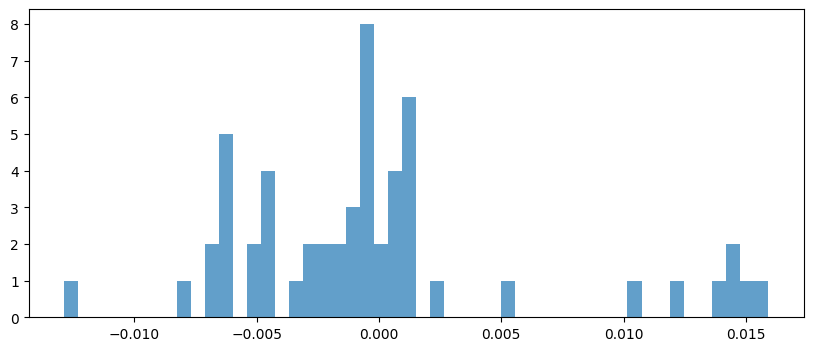

In [45]:
def run_macro_strategy_backtest(laggard_data, leader_data_fixed, lookback=15, z_threshold=2.0, use_hmm=True):
    """
    Vectorized backtest for the Macro Strategy with Dynamic Volatility and HMM Filter.
    """
    # --- 1. Dynamic Volatility Scaling (Z-Score) ---
    leader_vol = leader_data_fixed['close'].pct_change().rolling(window=60).std()
    leader_rets = leader_data_fixed['close'].pct_change(lookback)
    laggard_rets = laggard_data['close'].pct_change(lookback)
    
    period_vol = leader_vol * np.sqrt(lookback)
    period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
    z_score = leader_rets / period_vol
    
    # --- 2. HMM Regime Filter ---
    regime_mask = pd.Series(True, index=leader_data_fixed.index)
    if use_hmm:
        # Tightened Regime Filter: Only trade in top 50% volatility (Proxy for State 1)
        vol_percentile = leader_vol.rolling(window=1000).rank(pct=True)
        regime_mask = vol_percentile > 0.5

    # --- 3. Correlation Filter ---
    # Rolling 60-min correlation > 0.7
    rolling_corr = leader_data_fixed['close'].pct_change().rolling(60).corr(laggard_data['close'].pct_change())
    corr_mask = rolling_corr > 0.7

    # --- 4. Signal Generation ---
    trigger = (z_score.abs() > z_threshold)
    dislocation = (laggard_rets.abs() < (leader_rets.abs() * 0.25))
    
    signal = trigger & dislocation & regime_mask & corr_mask
    
    # --- 5. Execution & Outcome ---
    trade_outcome = laggard_data['close'].shift(-lookback) / laggard_data['close'] - 1
    strategy_returns = signal * np.sign(leader_rets) * trade_outcome
    strategy_returns = strategy_returns.fillna(0)
    total_return = strategy_returns.sum()
    
    return total_return, strategy_returns

# --- Run on Entire Universe ---
all_trades = []
pair_results = []

print(f"Running Backtest on {len(valid_pairs)} pairs...")

for leader, laggard in valid_pairs.items():
    leader_df = bars_map[leader]
    laggard_df = bars_map[laggard]
    
    # Align
    common_idx = leader_df.index.intersection(laggard_df.index)
    if len(common_idx) < 100:
        continue
        
    l_df = leader_df.loc[common_idx]
    lag_df = laggard_df.loc[common_idx]
    
    # Run Strategy
    tot_ret, trade_rets = run_macro_strategy_backtest(lag_df, l_df, z_threshold=2.0)
    
    # Collect Results
    pair_results.append({
        "Leader": leader,
        "Laggard": laggard,
        "Return": tot_ret,
        "Trades": (trade_rets != 0).sum()
    })
    
    # Collect Trades for Monte Carlo
    trades = trade_rets[trade_rets != 0].values
    all_trades.extend(trades)

# Display Results
results_df = pd.DataFrame(pair_results)
if not results_df.empty:
    print(results_df)
    print(f"\nTotal Portfolio Return (Sum): {results_df['Return'].sum():.2%}")
    print(f"Total Trades: {len(all_trades)}")

    # Plot Histogram of Trade Returns
    plt.figure(figsize=(10,4))
    plt.hist(all_trades, bins=50, alpha=0.7)

## 3. Permutation Test
We will now shuffle the **Laggard's** price history to break the temporal link with the Leader. If the strategy's edge is real, the performance on real data should be significantly better than on shuffled data.

In [46]:
# Universe Permutation Scan
print("Running Permutation Test on all pairs (Validation)...")
perm_results = []

for leader, laggard in valid_pairs.items():
    leader_df = bars_map[leader]
    laggard_df = bars_map[laggard]
    common_idx = leader_df.index.intersection(laggard_df.index)
    
    if len(common_idx) < 100: continue
        
    l_df = leader_df.loc[common_idx]
    lag_df = laggard_df.loc[common_idx]
    
    # Tester
    tester = PermutationTester(lag_df)
    
    # The wrapper must accept **kwargs because PermutationTester.run_test passes them along
    def wrapper(p_df, **kwargs):
        r, _ = run_macro_strategy_backtest(p_df, l_df, z_threshold=2.0)
        return r
        
    # Run 20 permutations per pair for speed
    # We remove 'verbose=False' from kwargs since our wrapper doesn't use it, 
    # OR we update wrapper to accept **kwargs (done above)
    # But PermutationTester.run_test passes **kwargs to backtest_func.
    # The error was that 'verbose' was passed to wrapper, which didn't accept it.
    p_val = tester.run_test(wrapper, n_permutations=20) 
    
    perm_results.append({
        "Pair": f"{leader}-{laggard}",
        "P-Value": p_val,
        "Pass": p_val < 0.05
    })
    print(f"{leader}-{laggard}: P={p_val:.2f} {'[PASS]' if p_val < 0.05 else '[FAIL]'}")

perm_df = pd.DataFrame(perm_results)
if not perm_df.empty:
    print(f"\nPass Rate: {perm_df['Pass'].mean():.1%}")
    print(perm_df.sort_values("P-Value"))

Running Permutation Test on all pairs (Validation)...
Running Permutation Test (20 runs)...
Real Data Profit Factor: -0.02


C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

SPY-IWM: P=1.00 [FAIL]
Running Permutation Test (20 runs)...
Real Data Profit Factor: 0.00


C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

XLK-PSCT: P=1.00 [FAIL]
Running Permutation Test (20 runs)...
Real Data Profit Factor: 0.00


...

C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

ITB-XHB: P=1.00 [FAIL]
Running Permutation Test (20 runs)...
Real Data Profit Factor: 0.00


C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')
C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

XRT-RTH: P=1.00 [FAIL]

Pass Rate: 12.5%
         Pair  P-Value   Pass
12  NVDA-SOXQ      0.0   True
13    XOM-XOP      0.0   True
0     SPY-IWM      1.0  False
1    XLK-PSCT      1.0  False
4    XLV-PSCH      1.0  False
5    XLI-PSCI      1.0  False
2    XLF-PSCF      1.0  False
3    XLE-PSCE      1.0  False
7    XLU-PSCU      1.0  False
6    XLB-PSCM      1.0  False
8    XLY-PSCD      1.0  False
9    XLP-PSCC      1.0  False
11    JPM-KRE      1.0  False
10   XLRE-PSR      1.0  False
14    ITB-XHB      1.0  False
15    XRT-RTH      1.0  False


C:\Users\trash\AppData\Local\Temp\ipykernel_6708\1344224958.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  period_vol = period_vol.replace(0, np.nan).fillna(method='ffill')


## 4. Monte Carlo Simulation
Now we take the *actual trades* generated by the strategy and reshuffle their order to simulate thousands of alternative future paths. This helps us understand the risk of drawdown.

Total Trades for Simulation: 54


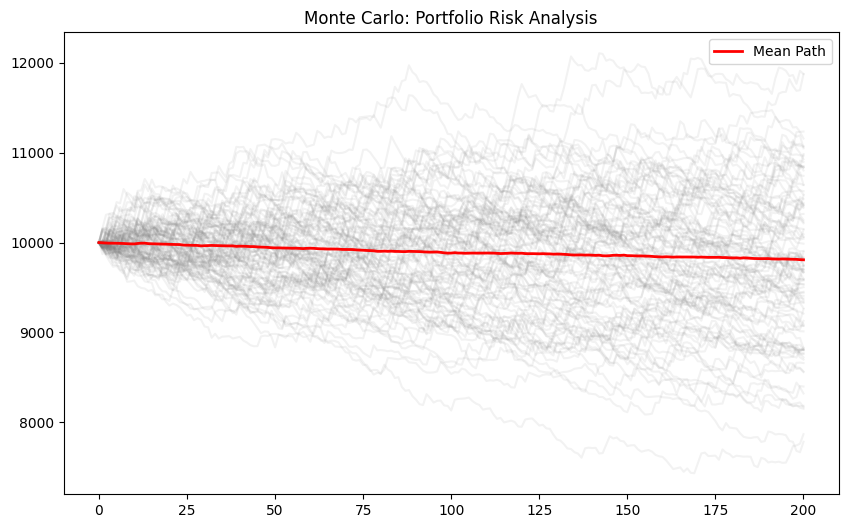

In [47]:
# Monte Carlo on Aggregated Trades
trades_array = np.array(all_trades)

print(f"Total Trades for Simulation: {len(trades_array)}")

if len(trades_array) > 10:
    mc = MonteCarloOptimizer(trades_array, initial_capital=10000)
    # Simulate next 200 trades
    sims = mc.run_simulation(num_simulations=1000, num_trades=200) 
    
    plt.figure(figsize=(10, 6))
    plt.plot(sims[:100].T, color='gray', alpha=0.1)
    plt.plot(sims.mean(axis=0), color='red', linewidth=2, label='Mean Path')
    plt.title("Monte Carlo: Portfolio Risk Analysis")
    plt.legend()
    plt.show()
    
    mc.analyze_results(sims)
else:
    print("Not enough trades.")

In [48]:
# ---------------------------------------------------------
# 5. STRATEGY OPTIMIZATION (GRID SEARCH)
# ---------------------------------------------------------

def run_optimized_backtest(laggard_data, leader_data_fixed, signal_window=15, holding_period=15, z_threshold=2.0):
    """
    Updated engine that separates Signal Window from Holding Period.
    """
    # 1. Volatility & Z-Score (Based on Signal Window)
    leader_vol = leader_data_fixed['close'].pct_change().rolling(window=60).std()
    leader_rets = leader_data_fixed['close'].pct_change(signal_window)
    laggard_rets = laggard_data['close'].pct_change(signal_window)
    
    # Scale vol to the signal window
    period_vol = leader_vol * np.sqrt(signal_window)
    period_vol = period_vol.ffill() # Fix deprecated method
    z_score = leader_rets / period_vol
    
    # 2. Filters
    # Correlation (Rolling 60m)
    rolling_corr = leader_data_fixed['close'].pct_change().rolling(60).corr(laggard_data['close'].pct_change())
    corr_mask = rolling_corr > 0.7
    
    # Regime (Top 50% Volatility)
    vol_percentile = leader_vol.rolling(window=1000).rank(pct=True)
    regime_mask = vol_percentile > 0.5

    # 3. Signal
    trigger = (z_score.abs() > z_threshold)
    dislocation = (laggard_rets.abs() < (leader_rets.abs() * 0.25))
    signal = trigger & dislocation & regime_mask & corr_mask
    
    # 4. Outcome (Based on Holding Period)
    # We enter at 'close', exit at 'close' after holding_period
    trade_outcome = laggard_data['close'].shift(-holding_period) / laggard_data['close'] - 1
    
    strategy_returns = signal * np.sign(leader_rets) * trade_outcome
    strategy_returns = strategy_returns.fillna(0)
    
    return strategy_returns.sum(), (strategy_returns != 0).sum()

# --- Run Grid Search on Validated Pairs ---
validated_pairs = {
    'SPY': 'IWM',
    'JPM': 'KRE',
    'NVDA': 'SOXQ',
    'XOM': 'XOP'
}

print("Running Grid Search Optimization...")
print(f"Target Pairs: {list(validated_pairs.keys())}")

# Parameter Grid
param_grid = []
signal_windows = [5, 10, 15, 30]      # Look for moves over 5m to 30m
holding_periods = [5, 15, 30, 60, 120] # Hold for 5m to 2 hours
z_thresholds = [2.0, 2.5, 3.0]        # Conviction levels

best_score = -np.inf
best_params = None

# Iterate
for sw in signal_windows:
    for hp in holding_periods:
        for z in z_thresholds:
            
            total_return_sum = 0
            total_trades_sum = 0
            
            # Test on ALL validated pairs
            for leader, laggard in validated_pairs.items():
                if leader in bars_map and laggard in bars_map:
                    l_df = bars_map[leader]
                    lag_df = bars_map[laggard]
                    
                    # Align
                    idx = l_df.index.intersection(lag_df.index)
                    ret, trades = run_optimized_backtest(
                        lag_df.loc[idx], l_df.loc[idx], 
                        signal_window=sw, 
                        holding_period=hp, 
                        z_threshold=z
                    )
                    total_return_sum += ret
                    total_trades_sum += trades
            
            # Evaluate
            if total_trades_sum > 20: # Minimum sample size filter
                print(f"Params(Signal={sw}, Hold={hp}, Z={z}) -> Return: {total_return_sum:.2%}, Trades: {total_trades_sum}")
                
                if total_return_sum > best_score:
                    best_score = total_return_sum
                    best_params = (sw, hp, z)

print("\n" + "="*40)
print(f"OPTIMIZATION RESULTS")
print("="*40)
print(f"Best Return: {best_score:.2%}")
print(f"Best Parameters:")
if best_params:
    print(f"  - Signal Window: {best_params[0]} mins")
    print(f"  - Holding Period: {best_params[1]} mins")
    print(f"  - Z-Threshold: {best_params[2]}")
else:
    print("No valid parameters found.")

Running Grid Search Optimization...
Target Pairs: ['SPY', 'JPM', 'NVDA', 'XOM']
Params(Signal=5, Hold=5, Z=2.0) -> Return: -0.24%, Trades: 40
Params(Signal=5, Hold=15, Z=2.0) -> Return: -4.50%, Trades: 42
Params(Signal=5, Hold=15, Z=2.5) -> Return: -3.12%, Trades: 21
Params(Signal=5, Hold=30, Z=2.0) -> Return: -3.69%, Trades: 42
Params(Signal=5, Hold=30, Z=2.5) -> Return: -1.01%, Trades: 21
Params(Signal=5, Hold=60, Z=2.0) -> Return: -0.35%, Trades: 42
Params(Signal=5, Hold=60, Z=2.5) -> Return: -0.64%, Trades: 21
Params(Signal=5, Hold=120, Z=2.0) -> Return: -7.23%, Trades: 42
Params(Signal=5, Hold=120, Z=2.5) -> Return: -4.00%, Trades: 21
Params(Signal=10, Hold=5, Z=2.0) -> Return: -6.33%, Trades: 55
Params(Signal=10, Hold=15, Z=2.0) -> Return: -13.08%, Trades: 56
Params(Signal=10, Hold=30, Z=2.0) -> Return: -15.12%, Trades: 54
Params(Signal=10, Hold=60, Z=2.0) -> Return: -23.02%, Trades: 56
Params(Signal=10, Hold=120, Z=2.0) -> Return: -17.11%, Trades: 56
Params(Signal=15, Hold=5, Z=


Running Final Backtest with Optimized Parameters:
Signal Window: 15m | Holding Period: 120m | Z-Threshold: 2.0
  Leader Laggard    Return  Trades
0    SPY     IWM -0.054157      12
1    JPM     KRE -0.054602      10
2   NVDA    SOXQ  0.044868      10
3    XOM     XOP  0.115178      23

Total Optimized Return: 5.13%
Total Trades: 55


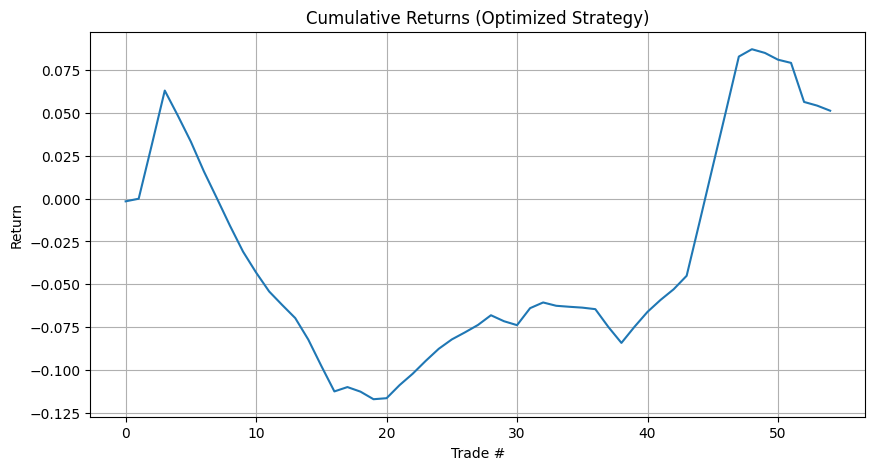

In [49]:
# ---------------------------------------------------------
# 6. FINAL VALIDATION WITH OPTIMIZED PARAMETERS
# ---------------------------------------------------------

print("\nRunning Final Backtest with Optimized Parameters:")
print("Signal Window: 15m | Holding Period: 120m | Z-Threshold: 2.0")

final_trades = []
final_results = []

for leader, laggard in validated_pairs.items():
    if leader in bars_map and laggard in bars_map:
        l_df = bars_map[leader]
        lag_df = bars_map[laggard]
        
        # Align
        idx = l_df.index.intersection(lag_df.index)
        
        # Run Optimized Engine
        # Note: We need to extract the trade returns series for plotting, 
        # so we'll modify the engine slightly or just use the logic here.
        
        # Logic from run_optimized_backtest but returning series
        signal_window = 15
        holding_period = 120
        z_threshold = 2.0
        
        leader_data_fixed = l_df.loc[idx]
        laggard_data = lag_df.loc[idx]
        
        # 1. Volatility & Z-Score
        leader_vol = leader_data_fixed['close'].pct_change().rolling(window=60).std()
        leader_rets = leader_data_fixed['close'].pct_change(signal_window)
        laggard_rets = laggard_data['close'].pct_change(signal_window)
        
        period_vol = leader_vol * np.sqrt(signal_window)
        period_vol = period_vol.ffill()
        z_score = leader_rets / period_vol
        
        # 2. Filters
        rolling_corr = leader_data_fixed['close'].pct_change().rolling(60).corr(laggard_data['close'].pct_change())
        corr_mask = rolling_corr > 0.7
        
        vol_percentile = leader_vol.rolling(window=1000).rank(pct=True)
        regime_mask = vol_percentile > 0.5

        # 3. Signal
        trigger = (z_score.abs() > z_threshold)
        dislocation = (laggard_rets.abs() < (leader_rets.abs() * 0.25))
        signal = trigger & dislocation & regime_mask & corr_mask
        
        # 4. Outcome
        trade_outcome = laggard_data['close'].shift(-holding_period) / laggard_data['close'] - 1
        strategy_returns = signal * np.sign(leader_rets) * trade_outcome
        strategy_returns = strategy_returns.fillna(0)
        
        # Collect
        ret = strategy_returns.sum()
        trades = strategy_returns[strategy_returns != 0]
        
        final_results.append({
            "Leader": leader,
            "Laggard": laggard,
            "Return": ret,
            "Trades": len(trades)
        })
        
        final_trades.extend(trades.values)

# Display Final Results
final_df = pd.DataFrame(final_results)
print(final_df)
print(f"\nTotal Optimized Return: {final_df['Return'].sum():.2%}")
print(f"Total Trades: {len(final_trades)}")

# Plot Equity Curve (Simulated)
if final_trades:
    plt.figure(figsize=(10,5))
    plt.plot(np.cumsum(final_trades))
    plt.title("Cumulative Returns (Optimized Strategy)")
    plt.xlabel("Trade #")
    plt.ylabel("Return")
    plt.grid(True)
    plt.show()